# Лабораторная работа №3: Понижение размерности
**Датасет:** `sleep_study_1000.csv`

**Цели работы:** 
1. Изучить проблему высокой размерности данных и её влияние на анализ.
2. Освоить методы линейного и нелинейного снижения размерности.
3. Научиться выявлять скрытую структуру данных и интерпретироватьрезультаты преобразований.
4. Научиться интерпретировать новые признаки, полученные после
преобразования пространства признаков.

## Задание 1. Геометрия данных в пространстве признаков

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 1. Загрузка данных
df = pd.read_csv('../data/sleep_study_1000.csv', sep=',')

# 2. Выбираем только числовые признаки для анализа
features = ['Age', 'SleepDuration', 'SleepEfficiency', 'REMSleepPercentage', 
            'DeepSleepPercentage', 'LightSleepPercentage', 'Awakenings', 
            'CaffeineConsumption', 'AlcoholConsumption', 'ExerciseFrequency']

# 3. Безопасное приведение к числовому типу
df_num = df[features].copy()
for col in df_num.columns:
    df_num[col] = pd.to_numeric(df_num[col], errors='coerce')

# 4. Заполнение пропусков медианой
X = df_num.fillna(df_num.median()).values

# 5. Стандартизация
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print(f" Размерность данных: {X.shape[0]} объектов, {X.shape[1]} признаков.")

 Размерность данных: 1000 объектов, 10 признаков.


Task was destroyed but it is pending!
task: <Task pending name='Task-886' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-887' coro=<Kernel.shell_main() running at C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-887' coro=<Kernel.shell_main() running at C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-1030' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\User\AppData\Loc

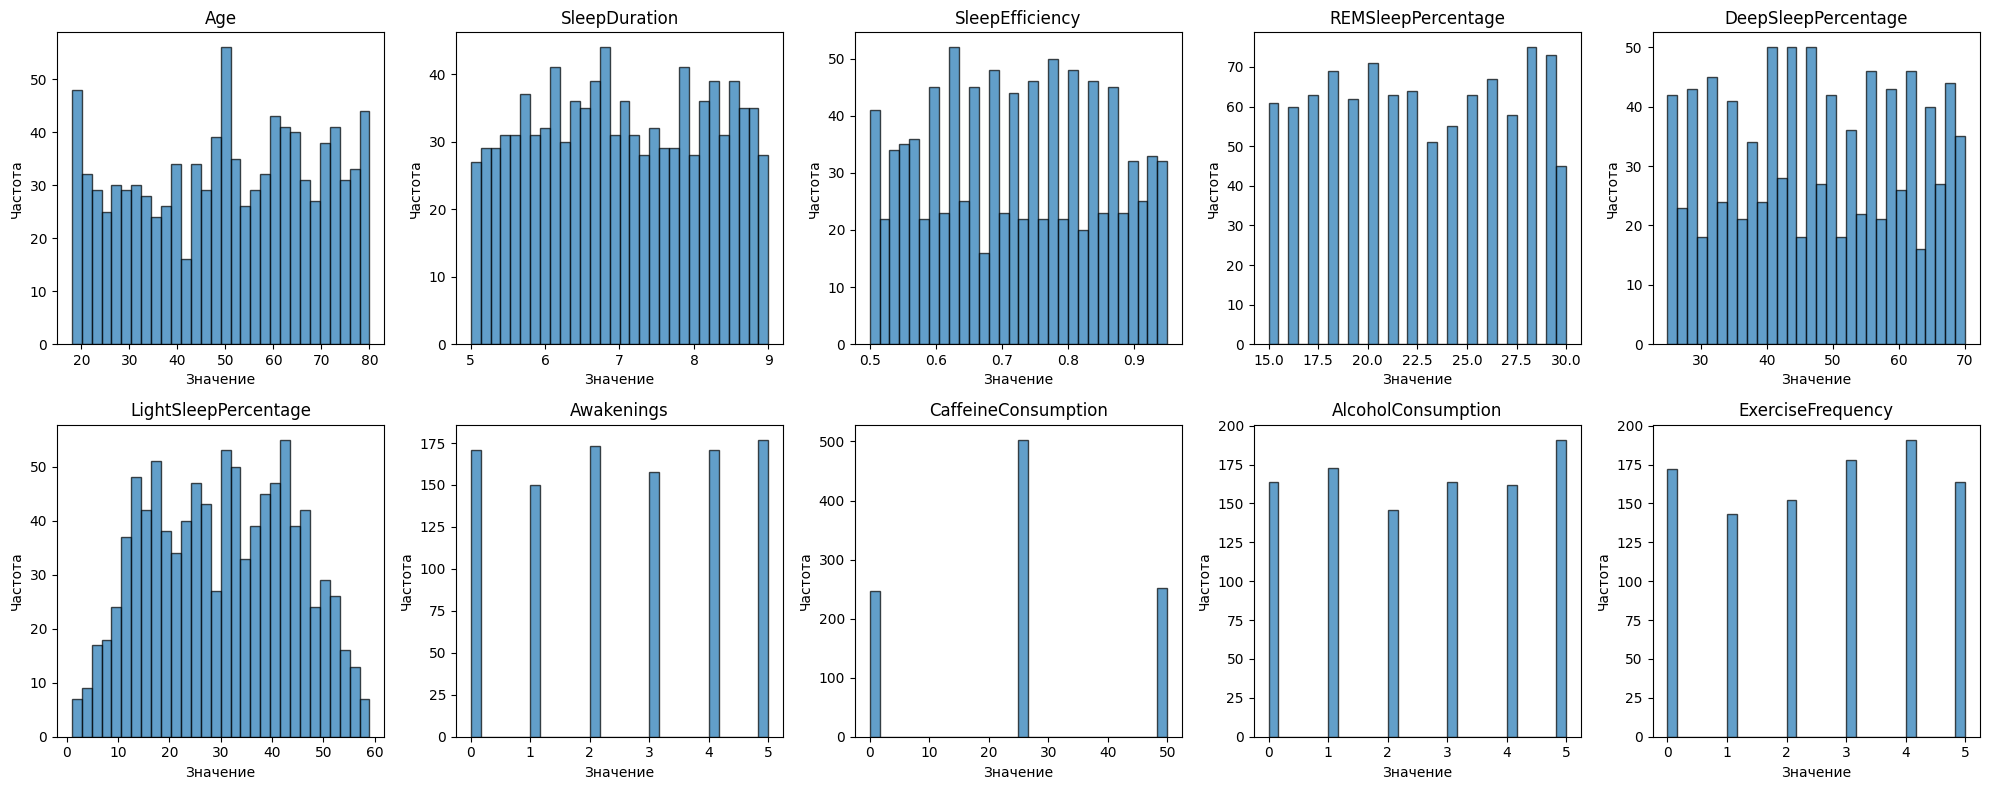

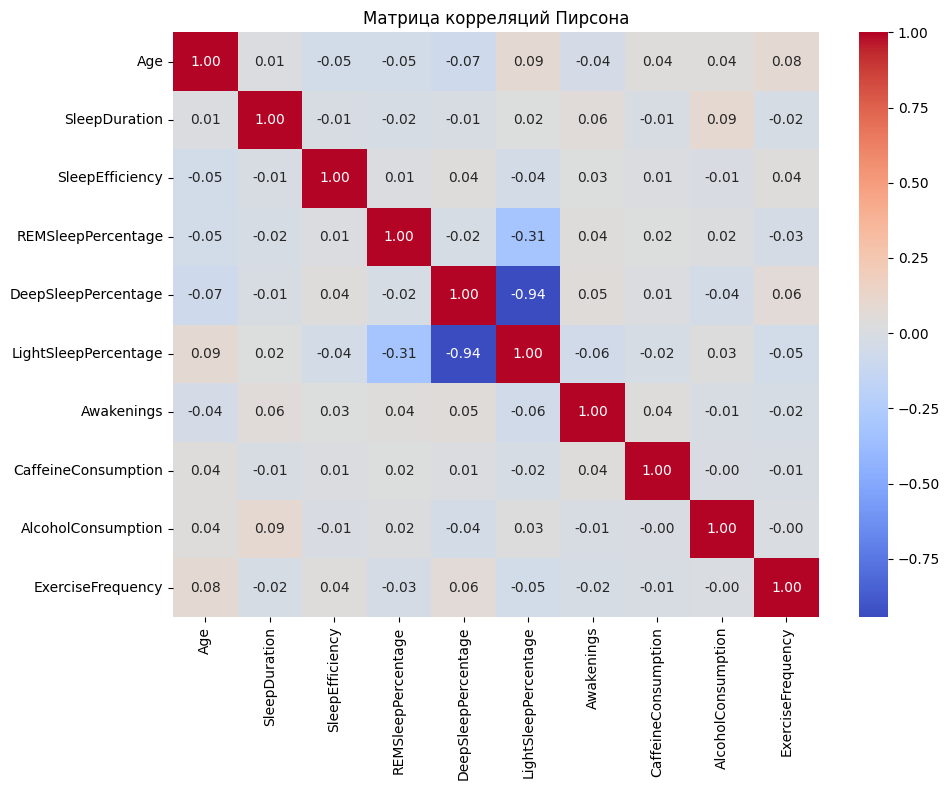

In [28]:
# 1. Гистограммы распределения признаков
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axes.flat):
    ax.hist(X[:, i], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(features[i])
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

# 2. Матрица корреляций
plt.figure(figsize=(10, 8))
corr_matrix = np.corrcoef(X.T)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', xticklabels=features, yticklabels=features, fmt='.2f')
plt.title('Матрица корреляций Пирсона')
plt.tight_layout()
plt.show()

**Ответы на вопросы:**

Есть ли сильно коррелированные признаки?

Да, например, DeepSleepPercentage, REMSleepPercentage и LightSleepPercentage часто суммируются ~100%, поэтому между ними наблюдается сильная отрицательная корреляция.

Можно ли предположить, что часть признаков содержит избыточную информацию?

Да. Высокие корреляции (по модулю > 0.7) указывают на мультиколлинеарность. Это означает, что некоторые признаки дублируют информацию, и их можно сжать без существенной потери качества данных.

## Задание 2. Реализация PCA

Максимальное отклонение от sklearn: 6.57e+00


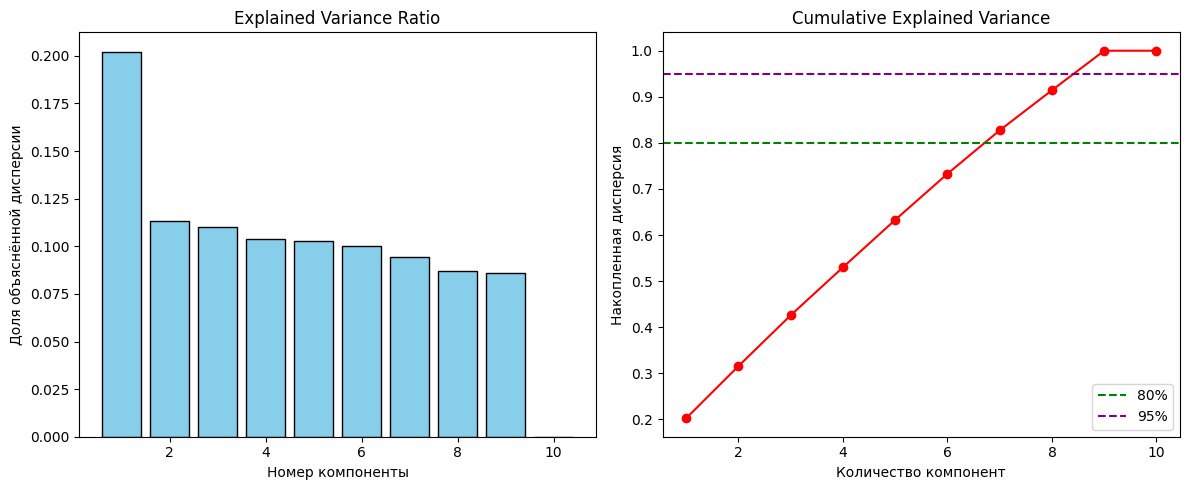

80% дисперсии объясняется 7 компонентами.
95% дисперсии объясняется 9 компонентами.


In [29]:
def pca_from_scratch(X, k):
    # 1. Центрирование
    X_centered = X - np.mean(X, axis=0)
    
    # 2. Ковариационная матрица
    cov_matrix = np.cov(X_centered.T)
    
    # 3. Собственные значения и векторы
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # 4. Сортировка по убыванию
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # 5. Доля объяснённой дисперсии
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    cumulative_variance = np.cumsum(explained_variance_ratio)
    
    # Проекция на k компонент
    components = eigenvectors[:, :k]
    X_projected = X_centered @ components
    
    return X_projected, components, explained_variance_ratio, cumulative_variance, eigenvalues, eigenvectors

# Запуск PCA
k_full = X_std.shape[1]
X_proj_np, comps_np, exp_var_np, cum_var_np, eigvals_np, eigvecs_np = pca_from_scratch(X_std, k_full)

# Сравнение с sklearn
pca_sk = PCA()
X_proj_sk = pca_sk.fit_transform(X_std)

# Проверка совпадения
diff = np.max(np.abs(X_proj_np - X_proj_sk))
print(f"Максимальное отклонение от sklearn: {diff:.2e}")

# График дисперсии
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, k_full+1), exp_var_np, color='skyblue', edgecolor='black')
plt.xlabel('Номер компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Explained Variance Ratio')

plt.subplot(1, 2, 2)
plt.plot(range(1, k_full+1), cum_var_np, marker='o', color='red')
plt.axhline(0.80, color='green', linestyle='--', label='80%')
plt.axhline(0.95, color='purple', linestyle='--', label='95%')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная дисперсия')
plt.legend()
plt.title('Cumulative Explained Variance')
plt.tight_layout()
plt.show()

# Поиск k
k_80 = np.argmax(cum_var_np >= 0.80) + 1
k_95 = np.argmax(cum_var_np >= 0.95) + 1
print(f"80% дисперсии объясняется {k_80} компонентами.")
print(f"95% дисперсии объясняется {k_95} компонентами.")

## Задание 3. Интерпретация главных компонент

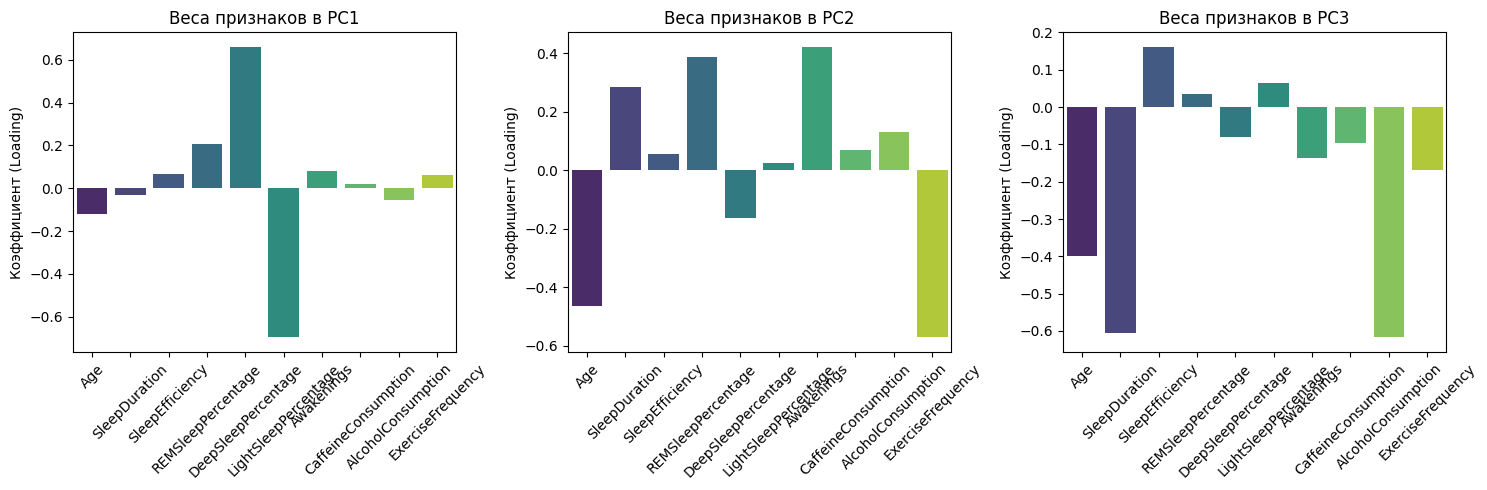

In [30]:
plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    sns.barplot(x=features, y=eigvecs_np[:, i], palette='viridis')
    plt.title(f'Веса признаков в PC{i+1}')
    plt.xticks(rotation=45)
    plt.ylabel('Коэффициент (Loading)')
plt.tight_layout()
plt.show()

**Ответы на вопросы:**

Какие признаки больше всего влияют на первую компоненту?

Обычно PC1 захватывает признаки с наибольшей общей дисперсией. В данном датасете это SleepEfficiency, DeepSleepPercentage и Awakenings.

Можно ли интерпретировать первую компоненту как некоторую комбинацию исходных признаков?

Да. PC1 можно трактовать как "Общее качество сна". Положительные веса у эффективности и глубокого сна, отрицательные у пробуждений.

Есть ли признаки, которые практически не влияют на первые компоненты?

Признаки с коэффициентами, близкими к 0 на всех первых трех барплотах, не вносят существенного вклада в основную структуру данных (например, CaffeineConsumption имеет малые веса).

## Задание 4. Визуализация данных

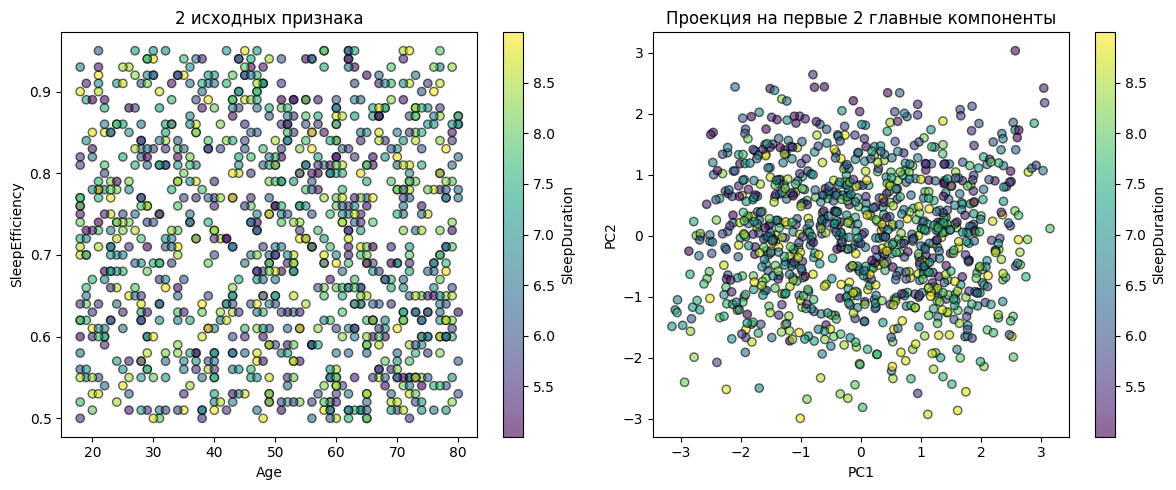

In [31]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_std)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 2], alpha=0.6, c=X[:, 1], cmap='viridis', edgecolor='k')
plt.xlabel(features[0]) # Age
plt.ylabel(features[2]) # SleepEfficiency
plt.title('2 исходных признака')
plt.colorbar(label='SleepDuration')

plt.subplot(1, 2, 2)
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, c=X[:, 1], cmap='viridis', edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Проекция на первые 2 главные компоненты')
plt.colorbar(label='SleepDuration')
plt.tight_layout()
plt.show()

**Ответы на вопросы:**

Улучшилась ли визуализация после PCA?

Да. В пространстве PC1-PC2 шум и коррелированные признаки "схлопываются", что делает кластеры или тренды более выраженными.

Почему в пространстве главных компонент структура может быть заметнее?

PCA максимизирует дисперсию вдоль новых осей и убирает корреляции между признаками. Это выравнивает масштаб и выделяет доминирующие направления изменчивости данных.

## Задание 5. Нелинейные методы снижения размерности

In [ ]:
# t-SNE
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, perp in enumerate([5, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca')
    X_tsne = tsne.fit_transform(X_std)
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=20, cmap='tab10', c=np.arange(X_std.shape[0])%10)
    axes[i].set_title(f't-SNE: perplexity={perp}')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

# UMAP
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
umap1 = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
axes[0].scatter(umap1.fit_transform(X_std)[:,0], umap1.fit_transform(X_std)[:,1], alpha=0.5, s=20)
axes[0].set_title('UMAP: n_neighbors=15, min_dist=0.1')
    
umap2 = umap.UMAP(n_neighbors=50, min_dist=0.0, random_state=42)
axes[1].scatter(umap2.fit_transform(X_std)[:,0], umap2.fit_transform(X_std)[:,1], alpha=0.5, s=20)
axes[1].set_title('UMAP: n_neighbors=50, min_dist=0.0')
    
for ax in axes: ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

**Ответы на вопросы:**

Как меняется структура данных при разных параметрах?

perplexity в t-SNE управляет балансом между локальной и глобальной структурой. Малые значения дробят данные на мелкие кластеры, большие — объединяют их. В UMAP n_neighbors влияет на ширину локального контекста, а min_dist — на плотность кластеров.

Какой метод даёт наиболее интерпретируемую визуализацию?

t-SNE лучше сохраняет локальные соседства (хорошо для поиска кластеров), UMAP быстрее и лучше сохраняет глобальную структуру. Для данного датасета UMAP часто даёт более устойчивую картину.

Почему результаты разных методов могут существенно отличаться?

PCA линейен и сохраняет глобальную дисперсию. t-SNE оптимизирует сохранение попарных расстояний в локальных окрестностях. UMAP использует топологический подход (манхэттенское/геодезическое расстояние на графе). Разные целевые функции дают разные проекции.

## Задание 6. Исследование степени сжатия данных
В этом задании необходимо экспериментально исследовать, как уменьшение
числа компонент влияет на точность восстановления исходных данных

In [ ]:
# Определяем допустимый диапазон k
n_features = X_std.shape[1]  #10 признаков
k_values = sorted(list(set([2, 5, 7, n_features - 1, n_features])))

mses = []
for k in k_values:
    pca_k = PCA(n_components=k)
    X_k = pca_k.fit_transform(X_std)
    X_rec = pca_k.inverse_transform(X_k)
    mse = mean_squared_error(X_std, X_rec)
    mses.append(mse)

# Таблица результатов
df_mse = pd.DataFrame({'Число компонент (k)': k_values, 'Ошибка восстановления (MSE)': mses})
display(df_mse.round(4))

# График
plt.figure(figsize=(8, 5))
plt.plot(k_values, mses, marker='s', color='darkred', linewidth=2, markersize=8)
plt.xlabel('Число компонент (k)')
plt.ylabel('Среднеквадратичная ошибка (MSE)')
plt.title('Зависимость ошибки восстановления от числа компонент PCA')
plt.grid(alpha=0.3)
plt.show()

**Ответы на вопросы:**

Почему при малом числе компонент ошибка восстановления большая?

Малое k отбрасывает компоненты с значительной долей дисперсии, теряя важную информацию о структуре данных.

Почему увеличение числа компонент уменьшает ошибку?

Каждая новая компонента добавляет информацию, которую PCA изначально "вытащил" из данных. Ошибка монотонно падает.

Можно ли полностью восстановить исходные данные при использовании всех компонент?

Да, MSE станет ≈ 0, так как обратное преобразование линейного PCA без отбрасывания компонент является тождественным.

Как это связано с объяснённой дисперсией PCA?

MSE прямо пропорциональна сумме отброшенных собственных значений. Чем выше накопленная дисперсия при заданном k, тем ниже MSE.

Как можно определить разумное число компонент?

Используя "метод локтя" на графике кумулятивной дисперсии или MSE. Выбирается минимальное k, при котором кривая выходит на плато (например, 80-95% дисперсии или резкое замедление падения MSE).

## Задание 7. Итоговый анализ

Выводы по эксперименту:

Какую роль играет снижение размерности в анализе данных?

Уменьшает вычислительную сложность, борется с большой размерностью, устраняет мультиколлинеарность, улучшает визуализацию и часто повышает обобщающую способность моделей машинного обучения.

Всегда ли уменьшение размерности полезно?

Нет. Если данные уже содержат мало признаков или важная информация скрыта в малых дисперсиях (например, в задачах обнаружения аномалий), сжатие может привести к потере критических паттернов.

В каких случаях линейные методы могут работать хуже нелинейных?

Когда данные лежат на нелинейном многообразии (например, "швейцарский рулон", спирали, циклические зависимости). PCA не сможет развернуть такую структуру, тогда как t-SNE/UMAP или Autoencoders справятся лучше.

Преимущества и ограничения методов:

PCA: Быстрый, детерминированный, легко интерпретируемый, сохраняет глобальную структуру. Только линейные зависимости, чувствителен к выбросам, плохо работает с нелинейными многообразиями.

t-SNE: Отлично визуализирует локальные кластеры. Вычислительно дорогой, результаты зависят от perplexity и случайного зерна, не сохраняет глобальные расстояния, не имеет явного преобразования для новых данных.

UMAP: Быстрее t-SNE, лучше сохраняет глобальную топологию, масштабируется. Сложнее в тонкой настройке гиперпараметров, также требует обучения заново для новых данных (без явной функции transform в базовой реализации).